In [1]:
import sys
sys.path.insert(0, "/data/biophys/schimmenti/Repositories/")
import torch
import torch.nn as nn
import torch.nn.functional as F
from diffusers import UNet2DModel, AutoencoderKL
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CIFAR10, CIFAR100, MNIST, STL10
import torchvision.transforms as T
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Dataset

In [2]:
DATASET = "mnist"

# --------------------------------------------------
# Transforms
# --------------------------------------------------

if DATASET == "mnist":

    tfm = T.Compose([
        T.Resize((32, 32)),
        T.Grayscale(num_output_channels=3),
        T.ToTensor(),
        T.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ])

elif DATASET in ["cifar10", "cifar100"]:

    tfm = T.Compose([
        T.ToTensor(),
        T.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ])

elif DATASET == "stl10":

    tfm = T.Compose([
        T.Resize((32, 32)),
        T.ToTensor(),
        T.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ])


# --------------------------------------------------
# Dataset
# --------------------------------------------------

if DATASET == "cifar100":

    dataset = CIFAR100(
        root="datasets/cifar100/",
        train=True,
        download=True,
        transform=tfm,
    )

    test_set = CIFAR100(
        root="datasets/cifar100/",
        train=False,
        download=True,
        transform=tfm,
    )

elif DATASET == "cifar10":

    dataset = CIFAR10(
        root="datasets/cifar10/",
        train=True,
        download=True,
        transform=tfm,
    )

    test_set = CIFAR10(
        root="datasets/cifar10/",
        train=False,
        download=True,
        transform=tfm,
    )

elif DATASET == "stl10":

    dataset = STL10(
        root="datasets/stl10/",
        split="train",
        download=True,
        transform=tfm,
    )

    test_set = STL10(
        root="datasets/stl10/",
        split="test",
        download=True,
        transform=tfm,
    )

elif DATASET == "mnist":

    dataset = MNIST(
        root="datasets/mnist/",
        train=True,
        download=True,
        transform=tfm,
    )

    test_set = MNIST(
        root="datasets/mnist/",
        train=False,
        download=True,
        transform=tfm,
    )

### Model

In [3]:

# --------------------------------------------------
# Continuous VP diffusion
#
# dx = -1/2 beta(t) x dt + sqrt(beta(t)) dW
#
# beta(t) = beta_min + t (beta_max - beta_min)
# --------------------------------------------------

beta_min = 0.1
beta_max = 20.0


def vp_alpha_sigma(t):
    """
    t: shape (B,), with t in [0, 1]

    Returns:
        alpha(t), sigma(t), each shape (B,)
    """

    log_alpha = (
        -0.5 * beta_min * t
        -0.25 * (beta_max - beta_min) * t**2
    )

    alpha = torch.exp(log_alpha)
    sigma = torch.sqrt(1.0 - alpha**2)

    return alpha, sigma


def add_vp_noise(x0, t):
    """
    x_t = alpha(t) x_0 + sigma(t) eps
    """

    eps = torch.randn_like(x0)

    alpha, sigma = vp_alpha_sigma(t)
    alpha = alpha.view(-1, *([1] * (x0.ndim - 1)))
    sigma = sigma.view(-1, *([1] * (x0.ndim - 1)))
    xt = alpha * x0 + sigma * eps

    return xt, eps




In [4]:
ae_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")
ae_model = ae_model.to(device).eval()
ae_model.requires_grad_(False)
ae_scaling = ae_model.config.scaling_factor

/home/schimmenti/miniconda3/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [5]:
with torch.no_grad():
    for batch in DataLoader(test_set, batch_size=1, shuffle=False):
        x0, _ = batch
        x0 = x0.to(device)
        latents = ae_model.encode(x0).latent_dist.sample()
        C_latents, H_latents, W_latents = latents.shape[1:]
        latents_shape = (C_latents, H_latents, W_latents)
        break

In [57]:
import camilla.models.vision as cml_vision
import camilla.models.misc as cml_misc

In [59]:
input_dim = C_latents * H_latents * W_latents
dae = cml_misc.ResidualDAE(input_dim, 128, tied=False).to(device)
num_epochs = 10
train_loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)
optimizer = torch.optim.Adam(dae.parameters(), lr=1e-3)
noise_aware = True

In [60]:
pbar = tqdm(range(num_epochs), desc="Training DAE")

for epoch in pbar:
    num_batches = len(train_loader)
    for batch_idx, batch in enumerate(train_loader):
        with torch.no_grad():
            image, _ = batch
            image = image.to(device)
            x_vae = ae_model.encode(image).latent_dist.sample()
            x0 = x_vae.view(x_vae.size(0), -1) * ae_scaling   # Flatten the latents for the DAE
        optimizer.zero_grad()
        t = torch.rand(x0.size(0), device=device)
        xt, eps = add_vp_noise(x0, t)
        if noise_aware:
            pred = dae(xt, t)
        else:
            pred = dae(xt)
        loss = (0.5*(pred-x0)**2).mean()
        loss.backward()
        optimizer.step()
        pbar.set_postfix({"epoch": epoch, "loss": loss.item(), "batch": f"{batch_idx+1}/{num_batches}"})

Training DAE:   0%|          | 0/10 [00:00<?, ?it/s]

In [28]:
with torch.no_grad():
    running_m1 = []
    running_m2 = []
    counts = 0
    for batch in tqdm(train_loader, desc="Estimating Covariance"):
        image, _ = batch
        image = image.to(device)
        x_vae = ae_model.encode(image).latent_dist.sample()
        x0 = x_vae.view(x_vae.size(0), -1).cpu() * ae_scaling
        running_m1.append(x0.sum(dim=0))
        running_m2.append( x0.T @ x0)
        counts += x0.size(0)
    running_m1 = torch.stack(running_m1)
    running_m2 = torch.stack(running_m2)
    mean = running_m1.sum(dim=0)/counts
    covariance = running_m2.sum(dim=0)/counts - mean[:, None] @ mean[None, :]

Estimating Covariance:   0%|          | 0/469 [00:00<?, ?it/s]

In [61]:
vals, vecs = torch.linalg.eigh(covariance)

In [84]:
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=4)
num_times = 100
num_iters = 20
eta = 0.1
with torch.no_grad():
    for batch in test_loader: 
        image, _ = batch
        image = image.to(device)
        x_vae = ae_model.encode(image).latent_dist.sample()
        x0 = x_vae.view(x_vae.size(0), -1) * ae_scaling
        
        x_preds = []
        x_pred_pcas = []
        for t_i in torch.linspace(0, 1, num_times):
            t = torch.full((x0.size(0),), t_i, device=device)
            xt, eps = add_vp_noise(x0, t)
            alpha, sigma = vp_alpha_sigma(t)
            x_pred = xt.clone()
            for _ in range(num_iters):
                x_pred += eta * (alpha.unsqueeze(1) * dae(x_pred, t) - x_pred)
            x_pred = x_pred.cpu()
            x_pred_pca = (x_pred - mean[None, :]) @ vecs
            x_preds.append(x_pred)
            x_pred_pcas.append(x_pred_pca)
        x0 = x0.cpu()
        x0_pca = (x0- mean[None, :]) @ vecs
        #image_pred = ae_model.decode(pred.view(-1, *latents_shape) / ae_scaling).sample
        break

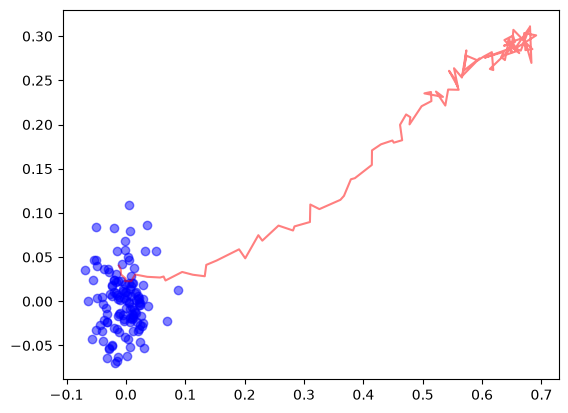

In [85]:
plt.scatter(x0_pca[:, 0], x0_pca[:, 1], color='blue', alpha=0.5, label='Original')
centroids = torch.stack([ x_pred_pca.mean(dim=0) for t_idx, x_pred_pca in enumerate(x_pred_pcas)])
plt.plot(centroids[:, 0], centroids[:, 1], color='red', alpha=0.5, label='Centroids')
plt.show()

In [62]:
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=4)
num_iters = 100
eta = 0.1
with torch.no_grad():
    for batch in test_loader: 
        image, _ = batch
        image = image.to(device)
        x_vae = ae_model.encode(image).latent_dist.sample()
        x0 = x_vae.view(x_vae.size(0), -1) * ae_scaling
        
        t = torch.full((x0.size(0),), 0.1, device=device)
        xt = add_vp_noise(x0, t)[0]
        if noise_aware:
            x_pred = dae(xt, t)
        else:
            x_pred = dae(xt)
            for _ in range(num_iters):
                x_pred += (dae(x_pred) - x_pred) * eta
        image_pred = ae_model.decode(x_pred.view(-1, C_latents, H_latents, W_latents) / ae_scaling).sample.cpu()
        x_pred = x_pred.cpu()
        x0 = x0.cpu()
        xt = xt.cpu()

        x0_pca = (x0 - mean) @ vecs
        xt_pca = (xt - mean) @ vecs
        x_pred_pca = (x_pred - mean) @ vecs
        break

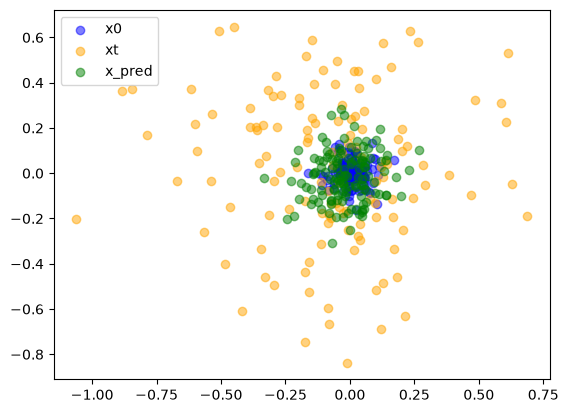

In [63]:
pca_to_plot= [3,4]
plt.scatter(x0_pca[:, pca_to_plot[0]].numpy(), x0_pca[:, pca_to_plot[1]].numpy(), alpha=0.5, label='x0', color='blue')
plt.scatter(xt_pca[:, pca_to_plot[0]].numpy(), xt_pca[:, pca_to_plot[1]].numpy(), alpha=0.5, label='xt', color='orange')
plt.scatter(x_pred_pca[:, pca_to_plot[0]].numpy(), x_pred_pca[:, pca_to_plot[1]].numpy(), alpha=0.5, label='x_pred', color='green')
plt.legend()

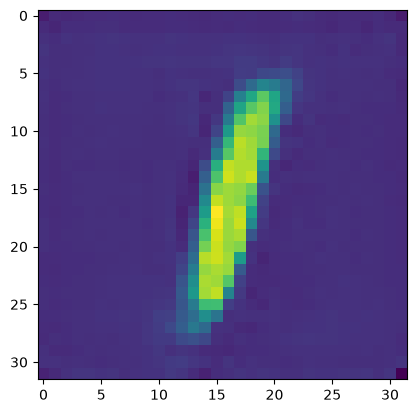

In [67]:
plt.imshow(image_pred[2,0])